# SQL Analytics on Online Retail Dataset

This notebook performs SQL-based analysis on the cleaned retail dataset.

Objectives:
- Analyze revenue patterns
- Identify top-selling products
- Examine revenue by country
- Explore monthly revenue trends

In [1]:
# Import Libraries
import pandas as pd
import sqlite3

In [2]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/retail_cleaned.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
# Create SQLite database in memory
conn = sqlite3.connect(":memory:") # This creates temporary SQL database

In [4]:
# Load dataset into SQL table
df.to_sql("retail", conn, index=False, if_exists="replace")

397884

In [5]:
# REVENUE BY COUNTRY
query = """
SELECT Country,
SUM(Revenue) AS Total_Revenue
FROM retail
GROUP BY Country
ORDER BY Total_Revenue DESC
"""

pd.read_sql(query, conn).head(10)

,Country,Total_Revenue
0,United Kingdom,7.308392e+06
1,Netherlands,2.854463e+05
2,EIRE,2.655459e+05
3,Germany,2.288671e+05
4,France,2.090240e+05
5,Australia,1.385213e+05
6,Spain,6.157711e+04
7,Switzerland,5.644395e+04
8,Belgium,4.119634e+04
9,Sweden,3.837833e+04


In [6]:
# TOP SELLING PRODUCTS
query = """
SELECT Description,
SUM(Quantity) AS Total_Quantity
FROM retail
GROUP BY Description
ORDER BY Total_Quantity DESC
LIMIT 10
"""

pd.read_sql(query, conn)

,Description,Total_Quantity
0,"PAPER CRAFT , LITTLE BIRDIE",80995
1,MEDIUM CERAMIC TOP STORAGE JAR,77916
2,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54415
3,JUMBO BAG RED RETROSPOT,46181
4,WHITE HANGING HEART T-LIGHT HOLDER,36725
5,ASSORTED COLOUR BIRD ORNAMENT,35362
6,PACK OF 72 RETROSPOT CAKE CASES,33693
7,POPCORN HOLDER,30931
8,RABBIT NIGHT LIGHT,27202
9,MINI PAINT SET VINTAGE,26076


In [7]:
# MOST PROFITABLE PRODUCT
query = """
SELECT Description,
SUM(Revenue) AS Total_Revenue
FROM retail
GROUP BY Description
ORDER BY Total_Revenue DESC
LIMIT 10
""" 
pd.read_sql(query, conn)

,Description,Total_Revenue
0,"PAPER CRAFT , LITTLE BIRDIE",168469.60
1,REGENCY CAKESTAND 3 TIER,142592.95
2,WHITE HANGING HEART T-LIGHT HOLDER,100448.15
3,JUMBO BAG RED RETROSPOT,85220.78
4,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
5,POSTAGE,77803.96
6,PARTY BUNTING,68844.33
7,ASSORTED COLOUR BIRD ORNAMENT,56580.34
8,Manual,53779.93
9,RABBIT NIGHT LIGHT,51346.20


In [8]:
# MONTHLY REVENUE
query = """
SELECT strftime('%Y-%m', InvoiceDate) AS Month,
SUM(Revenue) AS Monthly_Revenue
FROM retail
GROUP BY Month
ORDER BY Month
""" 
monthly_revenue = pd.read_sql(query, conn)

monthly_revenue.head()

,Month,Monthly_Revenue
0,2010-12,572713.890
1,2011-01,569445.040
2,2011-02,447137.350
3,2011-03,595500.760
4,2011-04,469200.361


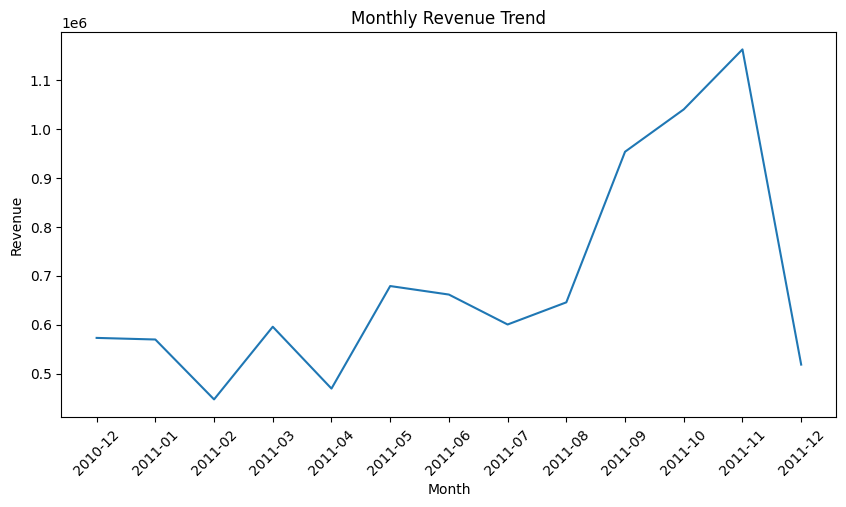

In [9]:
# Plot Monthly Revenue
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_revenue["Month"], monthly_revenue["Monthly_Revenue"])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [11]:
# CUSTOMER PURCHASE FREQUENCY
query = """
SELECT CustomerID, Country,
COUNT(DISTINCT InvoiceNo) AS Purchases
FROM retail
GROUP BY CustomerID
ORDER BY Purchases DESC
LIMIT 10
""" 
pd.read_sql(query, conn)

,CustomerID,Country,Purchases
0,12748.0,United Kingdom,209
1,14911.0,EIRE,201
2,17841.0,United Kingdom,124
3,13089.0,United Kingdom,97
4,14606.0,United Kingdom,93
5,15311.0,United Kingdom,91
6,12971.0,United Kingdom,86
7,14646.0,Netherlands,73
8,16029.0,United Kingdom,63
9,13408.0,United Kingdom,62
